# Análise da Matriz de Similaridade CUI

Explora a matriz `(N_images × N_cuis)` gerada pelo `run_cui_similarities.py`.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import pandas as pd
import csv
import matplotlib.pyplot as plt

# ── paths ──────────────────────────────────────────────────────────────────
RESULTS_DIR   = '../artifacts/results/cui_prediction'
OUTPUT_NAME   = 'cui_medsiglip_valid'
CONCEPTS_PATH = '../dev_caption/concepts.csv'
CUI_IDS_PATH  = '../artifacts/embeddings/IC2026_cui_mapping_ids.pt'

sim_matrix = torch.load(f'{RESULTS_DIR}/{OUTPUT_NAME}_sim_matrix.pt', weights_only=True)
image_ids  = torch.load(f'{RESULTS_DIR}/{OUTPUT_NAME}_image_ids.pt',  weights_only=True)
cui_ids    = torch.load(CUI_IDS_PATH, weights_only=True)

print(f'Similarity matrix : {tuple(sim_matrix.shape)}')
print(f'Images            : {len(image_ids)}')
print(f'CUIs              : {len(cui_ids)}')

Similarity matrix : (19240, 1934)
Images            : 19240
CUIs              : 1934


## 1. Estatísticas básicas

In [2]:
flat = sim_matrix.flatten().numpy()

print(f'Min    : {flat.min():.4f}')
print(f'Max    : {flat.max():.4f}')
print(f'Mean   : {flat.mean():.4f}')
print(f'Std    : {flat.std():.4f}')
for p in [50, 75, 90, 95, 99]:
    print(f'p{p:02d}   : {np.percentile(flat, p):.4f}')

Min    : -0.4997
Max    : 0.4532
Mean   : -0.0557
Std    : 0.1057
p50   : -0.0628
p75   : 0.0077
p90   : 0.0844
p95   : 0.1355
p99   : 0.2255


## 2. Distribuição de todas as similaridades

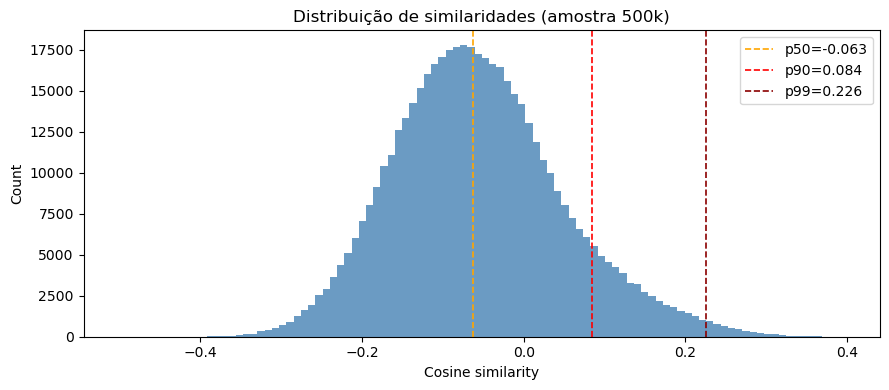

In [3]:
sample = flat[np.random.choice(len(flat), size=500_000, replace=False)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(sample, bins=100, color='steelblue', alpha=0.8, edgecolor='none')
for p, color in [(50, 'orange'), (90, 'red'), (99, 'darkred')]:
    v = np.percentile(flat, p)
    ax.axvline(v, color=color, linewidth=1.2, linestyle='--', label=f'p{p}={v:.3f}')
ax.set_xlabel('Cosine similarity')
ax.set_ylabel('Count')
ax.set_title('Distribuição de similaridades (amostra 500k)')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Ground truth: positivos vs negativos

Separa os valores de similaridade em pares onde o CUI **está** no GT da imagem (positivo) vs os que **não estão** (negativo). Essa é a análise mais importante para entender onde colocar o threshold — idealmente as duas distribuições se separam bem.

In [ ]:
gt = {}
with open(CONCEPTS_PATH, newline='', encoding='utf-8') as f:
    for row in csv.reader(f):
        if len(row) < 2: continue
        img_id = row[0].strip().replace('"', '')
        cuis   = row[1].strip().replace('"', '')
        gt[img_id] = set(cuis.split(';')) if cuis else set()

cui_to_col = {c: i for i, c in enumerate(cui_ids)}

pos_sims, neg_sims = [], []
n_sample_imgs = min(2000, len(image_ids))
rng_idx = np.random.choice(len(image_ids), size=n_sample_imgs, replace=False)

for i in rng_idx:
    img_id  = image_ids[i]
    gt_cuis = gt.get(img_id, set()) # CUIs do gt da imagem
    row_sim = sim_matrix[i].numpy() # similaridades da imagem com todas as CUIs
    for cui, col in cui_to_col.items():
        (pos_sims if cui in gt_cuis else neg_sims).append(row_sim[col]) # se CUI estiver no gt, é positivo

neg_sample = np.random.choice(neg_sims, size=min(len(neg_sims), 200_000), replace=False)

print(f'Positivos : {len(pos_sims):,}')
print(f'Negativos : {len(neg_sims):,}  (amostra: {len(neg_sample):,})')
print(f'\nPositivos — mean={np.mean(pos_sims):.4f}  p10={np.percentile(pos_sims,10):.4f}  p50={np.percentile(pos_sims,50):.4f}')
print(f'Negativos — mean={np.mean(neg_sample):.4f}  p90={np.percentile(neg_sample,90):.4f}  p99={np.percentile(neg_sample,99):.4f}')

Positivos : 6,204
Negativos : 3,861,796  (amostra: 200,000)

Positivos — mean=0.1035  p10=-0.0386  p50=0.1047
Negativos — mean=-0.0551  p90=0.0847  p99=0.2252


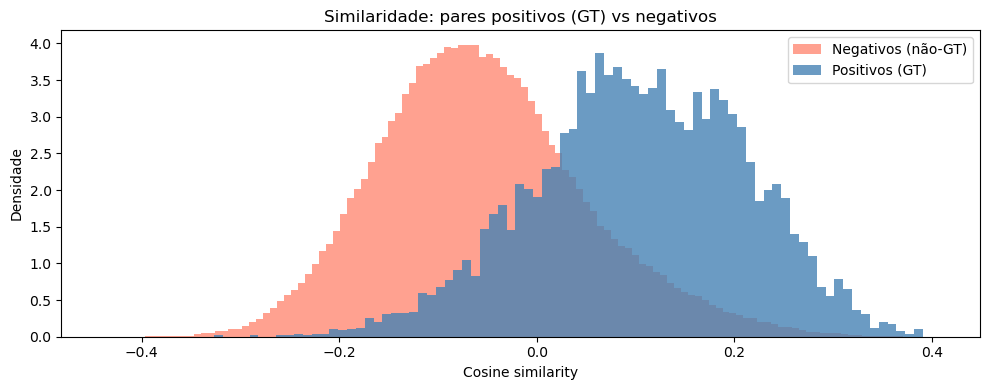

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(neg_sample, bins=120, color='tomato',    alpha=0.6, density=True, label='Negativos (não-GT)')
ax.hist(pos_sims,   bins=80,  color='steelblue', alpha=0.8, density=True, label='Positivos (GT)')
ax.set_xlabel('Cosine similarity')
ax.set_ylabel('Densidade')
ax.set_title('Similaridade: pares positivos (GT) vs negativos')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Quantos CUIs são preditos por imagem em função do threshold

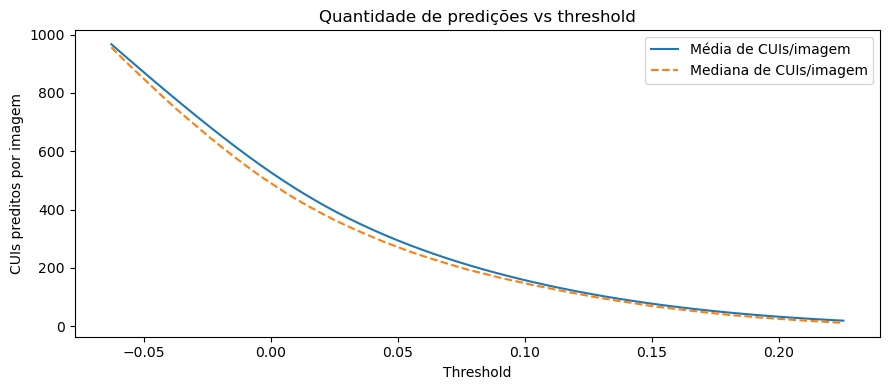

In [7]:
thresholds = np.linspace(float(np.percentile(flat, 50)), float(np.percentile(flat, 99)), 60)

mean_preds, median_preds = [], []
for t in thresholds:
    counts = (sim_matrix > t).sum(dim=1).float().numpy()
    mean_preds.append(counts.mean())
    median_preds.append(np.median(counts))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, mean_preds,   label='Média de CUIs/imagem')
ax.plot(thresholds, median_preds, label='Mediana de CUIs/imagem', linestyle='--')
ax.set_xlabel('Threshold')
ax.set_ylabel('CUIs preditos por imagem')
ax.set_title('Quantidade de predições vs threshold')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Curva F1 × threshold (após rodar o sweep)

```
preditos    = {CUIs com similaridade > threshold}
GT          = {CUIs do ground truth da imagem}
união       = preditos ∪ GT

y_pred = [1 se CUI em preditos else 0  para CUI in união]
y_true = [1 se CUI em GT       else 0  para CUI in união]

F1 = sklearn.f1_score(y_true, y_pred, average='binary')
```

- TP (acertou um CUI relevante) → aumenta F1
- FP (prediu um CUI errado) → reduz precision → reduz F1
- FN (perdeu um CUI do GT) → reduz recall → reduz F1
- TN (não prediu os 1931 irrelevantes) → não entra no cálculo

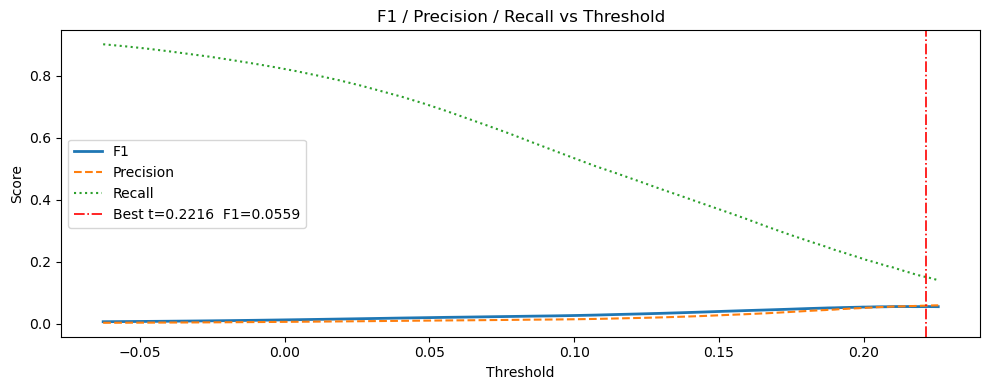

Melhor threshold : 0.2216
F1               : 0.0559
Precision        : 0.0592
Recall           : 0.1507


In [8]:
sweep_path = f'{RESULTS_DIR}/{OUTPUT_NAME}_threshold_sweep.csv'
try:
    df   = pd.read_csv(sweep_path)
    best = df.loc[df['f1'].idxmax()]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df['threshold'], df['f1'],        label='F1',        linewidth=2)
    ax.plot(df['threshold'], df['precision'], label='Precision', linestyle='--')
    ax.plot(df['threshold'], df['recall'],    label='Recall',    linestyle=':')
    ax.axvline(best['threshold'], color='red', linewidth=1.2, linestyle='-.',
               label=f"Best t={best['threshold']:.4f}  F1={best['f1']:.4f}")
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.set_title('F1 / Precision / Recall vs Threshold')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"Melhor threshold : {best['threshold']:.4f}")
    print(f"F1               : {best['f1']:.4f}")
    print(f"Precision        : {best['precision']:.4f}")
    print(f"Recall           : {best['recall']:.4f}")
except FileNotFoundError:
    print('Sweep ainda não executado. Rode primeiro:')
    print('  python run_cui_prediction.py --config configs/runs/cui_prediction.yaml --sweep')